# PCA 기초 실험 (Beer 화학 X=231)

이 노트북은 **PCA(주성분분석, Principal Component Analysis)** 를 “기초부터” 확인하기 위한 실험입니다.

## 무엇을 하는가
- 엑셀 파일에서
  - S1(화학 X 231개)
  - S4(관능 Y 50개, z-score)
  - 스타일 라벨 `tasting_category_fine`
  를 읽습니다.
- 결측치는 **평균 대치(mean imputation)**, 그 다음 **표준화(standardization)** 를 합니다.
- PCA를 두 방식으로 수행하고 비교합니다.
  1) **전체 데이터(250개) 기준 PCA**: 최대 231개 축(주성분)까지 생성 가능 → *학습용/이해용(Leakage 주의)*
  2) **Train(175개) 기준 PCA**: 최대 174개 축까지 생성 가능 → *모델링용(Leakage 없음)*

## 왜 Train에서는 231개 축이 안 나오나?
Train 샘플 수가 n=175이면, 평균 중심화(centering) 후 랭크(rank)가 최대 n-1=174라서  
PCA의 “분산>0”인 유효 축도 최대 174개입니다.

## 출력
- `/home/a202192020/맥주데이터실험/pca/output/` 아래에 타임스탬프 폴더를 만들고,
- PCA 객체(joblib), 변환 결과(npy), 로딩/설명분산(csv), 그림(png)을 저장합니다.


In [1]:
# (옵션) 필요한 패키지 설치
# - 서버에 이미 설치되어 있으면 이 셀은 건너뛰어도 됩니다.
!pip -q install pandas numpy scikit-learn openpyxl joblib matplotlib tqdm


In [2]:
import os, json
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import joblib
import matplotlib.pyplot as plt

# ====== 경로 설정 (사용자 제공) ======
XLSX_PATH = "/home/a202192020/맥주데이터실험/data/Supplemental Files and Figure source files.xlsx"
OUTPUT_ROOT = "/home/a202192020/맥주데이터실험/pca/output"

# 실행 타임스탬프 폴더
RUN_TS = datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_DIR = Path(OUTPUT_ROOT) / f"pca_basics_{RUN_TS}"
RUN_DIR.mkdir(parents=True, exist_ok=True)

print("XLSX_PATH:", XLSX_PATH)
print("RUN_DIR:", str(RUN_DIR))

# 재현성(랜덤 시드)
SEED = 42
np.random.seed(SEED)


XLSX_PATH: /home/a202192020/맥주데이터실험/data/Supplemental Files and Figure source files.xlsx
RUN_DIR: /home/a202192020/맥주데이터실험/pca/output/pca_basics_20260216_024802


In [3]:
# ====== 엑셀 로드 ======
from pathlib import Path

if not Path(XLSX_PATH).exists():
    raise FileNotFoundError(f"엑셀 파일을 찾을 수 없습니다: {XLSX_PATH}")

xls = pd.ExcelFile(XLSX_PATH)
print("Sheets:", xls.sheet_names[:10], "... (total:", len(xls.sheet_names), ")")

S1_NAME = "Supplementary File S1"
S4_NAME = "Supplementary File S4"

df_s1 = pd.read_excel(XLSX_PATH, sheet_name=S1_NAME)
df_s4 = pd.read_excel(XLSX_PATH, sheet_name=S4_NAME)

print("S1 shape:", df_s1.shape)
print("S4 shape:", df_s4.shape)

# 키/라벨 컬럼
ID_COL = "beer_id"
STYLE_COL = "tasting_category_fine"

for c in [ID_COL, STYLE_COL]:
    if c not in df_s1.columns:
        raise KeyError(f"S1에 {c} 컬럼이 없습니다.")
    if c not in df_s4.columns:
        raise KeyError(f"S4에 {c} 컬럼이 없습니다.")

# X/Y 컬럼 범위(논문/선배 코드에서 사용한 범위와 동일한 방식)
X_START, X_END = "acetaldehyde", "sulfur_sum"
Y_START, Y_END = "A_malt_all", "overall"

def cols_between(df, start, end):
    cols = list(df.columns)
    if start not in cols or end not in cols:
        return None
    i0, i1 = cols.index(start), cols.index(end)
    if i0 > i1:
        i0, i1 = i1, i0
    return cols[i0:i1+1]

X_COLS = cols_between(df_s1, X_START, X_END)
Y_COLS = cols_between(df_s4, Y_START, Y_END)

print("X_COLS:", len(X_COLS), " / first:", X_COLS[:3], " / last:", X_COLS[-3:])
print("Y_COLS:", len(Y_COLS), " / first:", Y_COLS[:3], " / last:", Y_COLS[-3:])

# 병합(안전하게 동일 샘플 정렬)
df = df_s1[[ID_COL, STYLE_COL] + X_COLS].merge(
    df_s4[[ID_COL] + Y_COLS],
    on=ID_COL,
    how="inner",
    validate="one_to_one",
)

print("Merged df shape:", df.shape)  # 기대: (250, 1+1+231+50 = 283)
print("Unique styles:", df[STYLE_COL].nunique())
print(df[STYLE_COL].value_counts().head(10))


Sheets: ['Supplementary File S1', 'Supplementary File S2', 'Supplementary File S3', 'Supplementary File S4', 'Supplementary File S5', 'Supplementary File S6', 'Supplementary File S7', 'Supplementary Table S1', 'Supplementary Table S2', 'Supplementary Table S3'] ... (total: 29 )
S1 shape: (250, 234)
S4 shape: (250, 53)
X_COLS: 231  / first: ['acetaldehyde', 'CS2', 'DES']  / last: ['aroma_hops_sum', 'acids_sum', 'sulfur_sum']
Y_COLS: 50  / first: ['A_malt_all', 'A_malt_grain', 'A_malt_bread']  / last: ['body', 'co2', 'overall']
Merged df shape: (250, 283)
Unique styles: 22
tasting_category_fine
Blond           31
Tripel          28
Strong ale      18
Hoppy           17
Stout/Porter    13
Wheat           12
Amber           12
Brown           12
Lambic          11
Pils/Lager      11
Name: count, dtype: int64


In [4]:
# ====== 결측치 확인 ======
X = df[X_COLS].to_numpy(dtype=float)
Y = df[Y_COLS].to_numpy(dtype=float)
styles = df[STYLE_COL].astype(str).to_numpy()

n, d = X.shape
print("n_samples:", n, "n_features(X):", d, "n_targets(Y):", Y.shape[1])

n_nan_X = np.isnan(X).sum()
n_nan_Y = np.isnan(Y).sum()
print("NaN count in X:", int(n_nan_X), f"({n_nan_X/(n*d)*100:.4f}%)")
print("NaN count in Y:", int(n_nan_Y), f"({n_nan_Y/(n*Y.shape[1])*100:.4f}%)")


n_samples: 250 n_features(X): 231 n_targets(Y): 50
NaN count in X: 73 (0.1264%)
NaN count in Y: 0 (0.0000%)


In [5]:
# ====== Outer split: 70/30, style stratify ======
def make_stratify_labels(y, min_count=2, rare_label="RARE"):
    # y: 1d array of labels (string)
    y = np.asarray(y, dtype=str)
    vc = pd.Series(y).value_counts()
    rare = set(vc[vc < min_count].index.tolist())
    out = np.array([rare_label if v in rare else v for v in y], dtype=str)
    return out

strat_labels = make_stratify_labels(styles, min_count=2)

idx_all = np.arange(n)
idx_tr, idx_te = train_test_split(
    idx_all,
    test_size=0.30,
    random_state=SEED,
    shuffle=True,
    stratify=strat_labels,
)

print("outer train:", len(idx_tr), "outer test:", len(idx_te))

# 스타일 분포 확인(층화가 잘 됐는지)
def style_dist(idxs):
    return pd.Series(styles[idxs]).value_counts()

dist_tr = style_dist(idx_tr)
dist_te = style_dist(idx_te)

dist_df = pd.DataFrame({"train": dist_tr, "test": dist_te}).fillna(0).astype(int)
dist_df["train_ratio"] = dist_df["train"] / dist_df["train"].sum()
dist_df["test_ratio"] = dist_df["test"] / dist_df["test"].sum()
dist_df = dist_df.sort_values("train", ascending=False)

display(dist_df.head(15))
dist_df.to_csv(RUN_DIR / "style_distribution_outer.csv", index=True)
print("saved:", RUN_DIR / "style_distribution_outer.csv")


outer train: 175 outer test: 75


,train,test,train_ratio,test_ratio
Blond,22,9,0.125714,0.120000
Tripel,20,8,0.114286,0.106667
Strong ale,13,5,0.074286,0.066667
Hoppy,12,5,0.068571,0.066667
Stout/Porter,9,4,0.051429,0.053333
Amber,8,4,0.045714,0.053333
Pils/Lager,8,3,0.045714,0.040000
Lambic,8,3,0.045714,0.040000
Wheat,8,4,0.045714,0.053333
Brown,8,4,0.045714,0.053333


saved: /home/a202192020/맥주데이터실험/pca/output/pca_basics_20260216_024802/style_distribution_outer.csv


In [6]:
# ====== PCA (ALL data) ======
# ⚠️ 이해/탐색용: 전체 데이터를 사용하므로, 이후 모델링의 '공정 평가'에는 쓰지 마세요(Leakage 위험).
# 하지만 '231개 축'을 실제로 뽑아보고 저장/시각화하는 기초 실험에는 유용합니다.

X_all = X.copy()

imp_all = SimpleImputer(strategy="mean")
scaler_all = StandardScaler()

X_all_imp = imp_all.fit_transform(X_all)
X_all_s = scaler_all.fit_transform(X_all_imp)

# 전체 데이터는 n=250, d=231 → min(n-1, d)=231개 축까지 가능
max_pc_all = min(X_all_s.shape[0]-1, X_all_s.shape[1])
print("max_pc_all:", max_pc_all)

pca_all = PCA(n_components=max_pc_all, random_state=SEED, svd_solver="full")
Z_all = pca_all.fit_transform(X_all_s)

print("Z_all shape:", Z_all.shape)
print("Explained variance ratio sum:", float(pca_all.explained_variance_ratio_.sum()))

# 저장
all_dir = RUN_DIR / "pca_all_250"
all_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(imp_all, all_dir / "imputer.joblib")
joblib.dump(scaler_all, all_dir / "scaler.joblib")
joblib.dump(pca_all, all_dir / "pca.joblib")

np.save(all_dir / "X_scaled.npy", X_all_s)
np.save(all_dir / "Z_full.npy", Z_all)
np.save(all_dir / "components.npy", pca_all.components_)  # (n_components, d)

evr = pd.DataFrame({
    "pc": np.arange(1, len(pca_all.explained_variance_ratio_)+1),
    "explained_variance_ratio": pca_all.explained_variance_ratio_,
})
evr["cumulative_evr"] = evr["explained_variance_ratio"].cumsum()
evr.to_csv(all_dir / "explained_variance.csv", index=False)

print("saved all PCA artifacts to:", all_dir)


max_pc_all: 231
Z_all shape: (250, 231)
Explained variance ratio sum: 0.9999999999999998
saved all PCA artifacts to: /home/a202192020/맥주데이터실험/pca/output/pca_basics_20260216_024802/pca_all_250


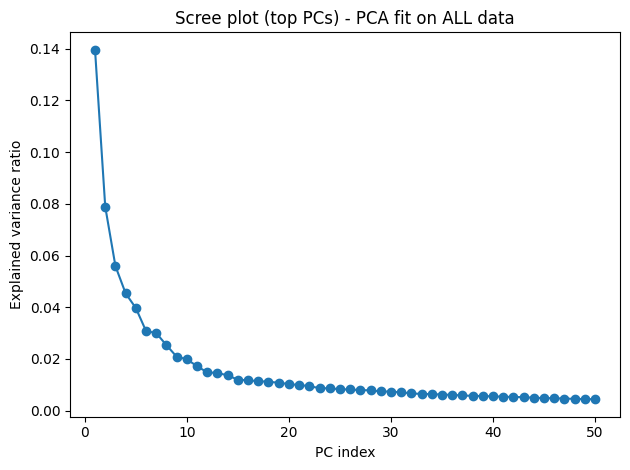

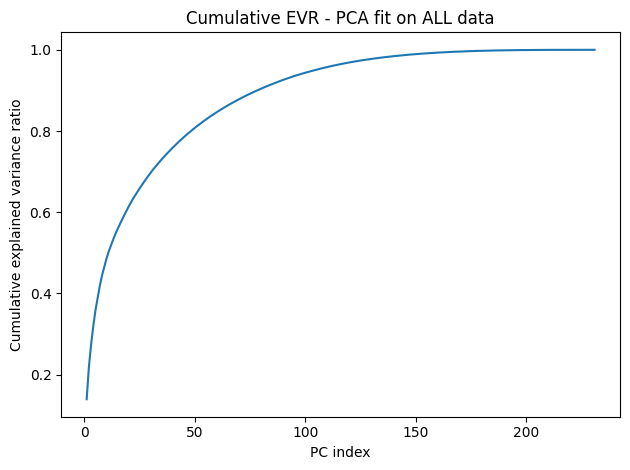

saved plots to: /home/a202192020/맥주데이터실험/pca/output/pca_basics_20260216_024802/pca_all_250


In [7]:
# ====== Scree plot / cumulative EVR (ALL) ======
all_dir = RUN_DIR / "pca_all_250"
evr = pd.read_csv(all_dir / "explained_variance.csv")

# Scree: 상위 50개만 보기
top = min(50, len(evr))

plt.figure()
plt.plot(evr["pc"][:top], evr["explained_variance_ratio"][:top], marker="o")
plt.xlabel("PC index")
plt.ylabel("Explained variance ratio")
plt.title("Scree plot (top PCs) - PCA fit on ALL data")
plt.tight_layout()
plt.savefig(all_dir / "scree_top50.png", dpi=150)
plt.show()

plt.figure()
plt.plot(evr["pc"], evr["cumulative_evr"])
plt.xlabel("PC index")
plt.ylabel("Cumulative explained variance ratio")
plt.title("Cumulative EVR - PCA fit on ALL data")
plt.tight_layout()
plt.savefig(all_dir / "cumulative_evr.png", dpi=150)
plt.show()

print("saved plots to:", all_dir)


In [8]:
# ====== PCA (TRAIN only) ======
# ✅ 모델링용: train에만 fit하고 test는 transform만 합니다.

X_tr = X[idx_tr]
X_te = X[idx_te]

imp_tr = SimpleImputer(strategy="mean")
scaler_tr = StandardScaler()

X_tr_imp = imp_tr.fit_transform(X_tr)
X_tr_s = scaler_tr.fit_transform(X_tr_imp)

X_te_imp = imp_tr.transform(X_te)
X_te_s = scaler_tr.transform(X_te_imp)

max_pc_tr = min(X_tr_s.shape[0]-1, X_tr_s.shape[1])
print("max_pc_train:", max_pc_tr)

pca_tr = PCA(n_components=max_pc_tr, random_state=SEED, svd_solver="full")
Z_tr = pca_tr.fit_transform(X_tr_s)
Z_te = pca_tr.transform(X_te_s)

print("Z_tr shape:", Z_tr.shape, "Z_te shape:", Z_te.shape)
print("Explained variance ratio sum:", float(pca_tr.explained_variance_ratio_.sum()))

# 저장
tr_dir = RUN_DIR / "pca_train_175"
tr_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(imp_tr, tr_dir / "imputer.joblib")
joblib.dump(scaler_tr, tr_dir / "scaler.joblib")
joblib.dump(pca_tr, tr_dir / "pca.joblib")

np.save(tr_dir / "X_train_scaled.npy", X_tr_s)
np.save(tr_dir / "X_test_scaled.npy", X_te_s)
np.save(tr_dir / "Z_train_full.npy", Z_tr)
np.save(tr_dir / "Z_test_full.npy", Z_te)
np.save(tr_dir / "components.npy", pca_tr.components_)

evr_tr = pd.DataFrame({
    "pc": np.arange(1, len(pca_tr.explained_variance_ratio_)+1),
    "explained_variance_ratio": pca_tr.explained_variance_ratio_,
})
evr_tr["cumulative_evr"] = evr_tr["explained_variance_ratio"].cumsum()
evr_tr.to_csv(tr_dir / "explained_variance.csv", index=False)

# split 인덱스 저장(재현용)
meta = {
    "seed": SEED,
    "n_total": int(n),
    "n_train": int(len(idx_tr)),
    "n_test": int(len(idx_te)),
    "n_features": int(d),
    "max_pc_all": int(min(n-1, d)),
    "max_pc_train": int(max_pc_tr),
    "xlsx_path": XLSX_PATH,
}
with open(RUN_DIR / "meta.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

with open(RUN_DIR / "outer_split_indices.json", "w", encoding="utf-8") as f:
    json.dump({"train_idx": idx_tr.tolist(), "test_idx": idx_te.tolist()}, f, ensure_ascii=False, indent=2)

print("saved train PCA artifacts to:", tr_dir)
print("saved meta to:", RUN_DIR / "meta.json")


max_pc_train: 174
Z_tr shape: (175, 174) Z_te shape: (75, 174)
Explained variance ratio sum: 1.0
saved train PCA artifacts to: /home/a202192020/맥주데이터실험/pca/output/pca_basics_20260216_024802/pca_train_175
saved meta to: /home/a202192020/맥주데이터실험/pca/output/pca_basics_20260216_024802/meta.json


In [9]:
# ====== PCA 성질 체크(직교/비상관) ======
tr_dir = RUN_DIR / "pca_train_175"
pca_tr = joblib.load(tr_dir / "pca.joblib")
Z_tr = np.load(tr_dir / "Z_train_full.npy")

# (1) components는 직교여야 함: components @ components^T ≈ I
C = pca_tr.components_
I_approx = C @ C.T
off_diag = I_approx - np.eye(I_approx.shape[0])
max_off = float(np.abs(off_diag).max())
print("max |off-diagonal| of (C C^T - I):", max_off)

# (2) score(Z)는 서로 상관이 0에 가까움(표본 오차로 완전 0은 아님)
# 상위 10개만 확인
Z10 = Z_tr[:, :10]
corr = np.corrcoef(Z10, rowvar=False)
max_off_corr = float(np.abs(corr - np.eye(10)).max())
print("max |off-diagonal| of corr(Z[:,:10]):", max_off_corr)


max |off-diagonal| of (C C^T - I): 2.7755575615628914e-15
max |off-diagonal| of corr(Z[:,:10]): 9.582374523631108e-16


,k,train_recon_mse,test_recon_mse,cum_evr
0,1,8.548578e-01,0.865006,0.145142
1,2,7.751774e-01,0.792220,0.224823
2,5,6.311509e-01,0.684557,0.368849
3,10,4.988670e-01,0.592588,0.501133
4,20,3.631848e-01,0.513917,0.636815
5,50,1.580575e-01,0.392619,0.841943
6,100,3.200451e-02,0.255823,0.967995
7,174,4.075958e-30,0.090627,1.000000


saved: /home/a202192020/맥주데이터실험/pca/output/pca_basics_20260216_024802/pca_train_175/reconstruction_vs_k.csv


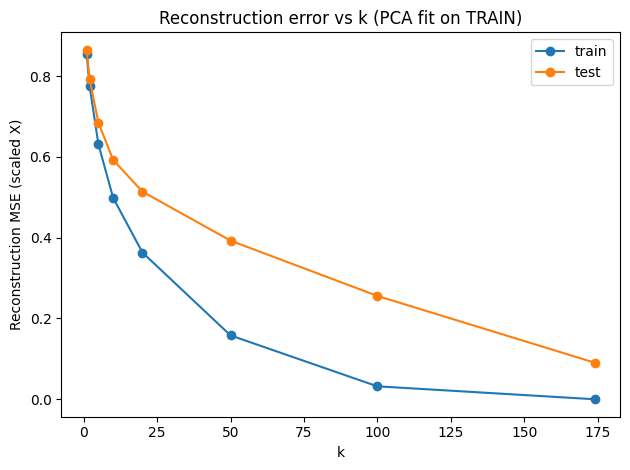

In [10]:
# ====== 재구성 오차(reconstruction error) vs k ======
# PCA는 k가 커질수록 재구성 오차가 감소해야 합니다.

tr_dir = RUN_DIR / "pca_train_175"
X_tr_s = np.load(tr_dir / "X_train_scaled.npy")
X_te_s = np.load(tr_dir / "X_test_scaled.npy")
pca_tr = joblib.load(tr_dir / "pca.joblib")

C = pca_tr.components_  # (kmax, d)
mu = pca_tr.mean_       # (d,)

def recon_mse(Xs, k):
    Zk = (Xs - mu) @ C[:k].T
    Xhat = Zk @ C[:k] + mu
    return float(np.mean((Xs - Xhat) ** 2))

kmax = C.shape[0]
k_list = [1, 2, 5, 10, 20, 50, 100, kmax]
k_list = sorted(list(dict.fromkeys([k for k in k_list if k <= kmax])))

rows = []
for k in k_list:
    rows.append({
        "k": k,
        "train_recon_mse": recon_mse(X_tr_s, k),
        "test_recon_mse": recon_mse(X_te_s, k),
        "cum_evr": float(pca_tr.explained_variance_ratio_[:k].sum()),
    })

df_recon = pd.DataFrame(rows)
display(df_recon)

df_recon.to_csv(tr_dir / "reconstruction_vs_k.csv", index=False)
print("saved:", tr_dir / "reconstruction_vs_k.csv")

plt.figure()
plt.plot(df_recon["k"], df_recon["train_recon_mse"], marker="o", label="train")
plt.plot(df_recon["k"], df_recon["test_recon_mse"], marker="o", label="test")
plt.xlabel("k")
plt.ylabel("Reconstruction MSE (scaled X)")
plt.title("Reconstruction error vs k (PCA fit on TRAIN)")
plt.legend()
plt.tight_layout()
plt.savefig(tr_dir / "reconstruction_vs_k.png", dpi=150)
plt.show()


In [11]:
# ====== 로딩(loadings) 상위 변수 보기 (PC1~PC5) ======
tr_dir = RUN_DIR / "pca_train_175"
pca_tr = joblib.load(tr_dir / "pca.joblib")
C = pca_tr.components_  # (kmax, d)

topk = 15
pcs_to_show = min(5, C.shape[0])

records = []
for pc_idx in range(pcs_to_show):
    vec = C[pc_idx]
    order = np.argsort(np.abs(vec))[::-1][:topk]
    for rank, j in enumerate(order, start=1):
        records.append({
            "pc": pc_idx + 1,
            "rank": rank,
            "feature": X_COLS[j],
            "loading": float(vec[j]),
            "abs_loading": float(abs(vec[j])),
        })

df_top = pd.DataFrame(records)
display(df_top.head(30))

df_top.to_csv(tr_dir / "top_loadings_pc1_to_pc5.csv", index=False)
print("saved:", tr_dir / "top_loadings_pc1_to_pc5.csv")


,pc,rank,feature,loading,abs_loading
0,1,1,neryl.propanoate,-0.159274,0.159274
1,1,2,n.dodecanol,-0.154316,0.154316
2,1,3,X4.methyl.1.pentanol,-0.152925,0.152925
3,1,4,n.decanol,-0.152364,0.152364
4,1,5,n.nonanol,-0.150110,0.150110
5,1,6,ethyl..9..decenoate,-0.148037,0.148037
6,1,7,ethyl..E..cinnamate,-0.144711,0.144711
7,1,8,caryophyllene.alcohol,-0.141442,0.141442
8,1,9,delta.terpinyl.acetate,-0.135569,0.135569
9,1,10,alpha.calacorene,-0.134311,0.134311


saved: /home/a202192020/맥주데이터실험/pca/output/pca_basics_20260216_024802/pca_train_175/top_loadings_pc1_to_pc5.csv


In [12]:
print("DONE. Outputs saved under:", RUN_DIR)


DONE. Outputs saved under: /home/a202192020/맥주데이터실험/pca/output/pca_basics_20260216_024802
